## Building a Basic Chatbot Using LangGraph(Graph API)

In [1]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

In [2]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

graph_builder = StateGraph(State)

In [3]:
import os
from dotenv import load_dotenv

load_dotenv()

True

In [4]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

llm = ChatGroq(model_name = "llama-3.1-8b-instant")

In [5]:
## Node Functionality
def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}


In [6]:
graph_builder = StateGraph(State)

##Add nodes to the graph
graph_builder.add_node("chat_bot", chatbot)

#Connect the nodes through edges
graph_builder.add_edge(START, "chat_bot")
graph_builder.add_edge("chat_bot", END)

#Compile the graph
graph = graph_builder.compile()

### Visualizing the Graph

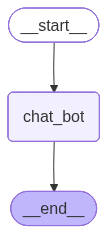

In [7]:
from IPython.display import Image, display
try: 
    display(Image(graph.get_graph().draw_mermaid_png()))
except:
    pass

In [8]:
response = graph.invoke({"messages":"Hi"})
print(response["messages"][-1].content)

How can I assist you today?


In [9]:
for event in graph.stream({"messages": "Hi"}):
    for value in event.values():
        print(value["messages"][-1].content)

It's nice to meet you. Is there something I can help you with or would you like to chat?


## ChatBot with Tools

In [10]:
from langchain_tavily import TavilySearch

tavilyTool = TavilySearch(max_results = 2)

tavilyTool.invoke("What is the capital of France?")

{'query': 'What is the capital of France?',
 'response_time': 1.13,
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://simple.wikipedia.org/wiki/Capital_of_France',
   'title': 'Capital of France - Simple English Wikipedia, the free encyclopedia',
   'content': 'The **capital of France** is Paris. In the course of history, the national capital has been in many locations other than Paris. * Versailles (1871–1879) The French Third Republic established Versailles as its seat of government in March 1871 after the Paris Commune took control of Paris. * Bordeaux (September 1914) The French government was relocated from Paris to Bordeaux very briefly during World War I, when it was feared that Paris would soon fall into German hands. * Tours (10–13 June 1940) Tours served as the temporary capital of France during the Second World War after the government fled Paris due to the German advance. * Bordeaux (June 1940) The French government was relocated fr

In [11]:
## Custom Multiplication function
def multiply(a:int, b:int) -> int:
    """
    Multiplies two numbers

    Args:
        a (int): The first int
        b (int): The second int

    Returns:
        int: Output int
    """
    return a * b


In [12]:
tools = [tavilyTool, multiply]

In [13]:
llm_with_tools = llm.bind_tools(tools)


In [14]:
llm_with_tools

RunnableBinding(bound=ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 8192, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x00000208F949BE00>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x00000208F9630C20>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********')), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need to answer questions about current events. It not only retrieves URLs and snippets, but offers advanced search depths, domain management, time range filters, and image search, this tool delivers real-time, accurate, and citation-backed results.Input sho

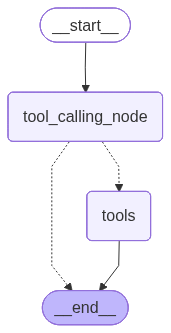

In [15]:
from langgraph.graph import StateGraph, END, START
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

def tool_calling_node(state: State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}


tool_graph_builder = StateGraph(State)
tool_graph_builder.add_node("tool_calling_node", tool_calling_node)
tool_graph_builder.add_node("tools", ToolNode(tools))


tool_graph_builder.add_edge(START, "tool_calling_node")
tool_graph_builder.add_conditional_edges(
    "tool_calling_node",
    # If the latest message (result) from llm is a tool call -> go to tool_container_node
    # If the latest message (result) from llm is not a tool call -> go to END
    tools_condition,
    ["tools", END]
)
tool_graph_builder.add_edge("tools", END)

tool_graph = tool_graph_builder.compile()
try: 
    display(Image(tool_graph.get_graph().draw_mermaid_png()))
except:
    pass

In [18]:
response = tool_graph.invoke({"messages": "What is the weather like in Webster Grooves?"})
print(response["messages"][-1].content)

{"query": "weather in Webster Groves", "response_time": 1.78, "follow_up_questions": null, "answer": null, "images": [], "results": [{"title": "Weather in Webster Groves, Missouri", "url": "https://www.weatherapi.com/", "content": "{'location': {'name': 'Webster Groves', 'region': 'Missouri', 'country': 'United States of America', 'lat': 38.5925, 'lon': -90.3572, 'tz_id': 'America/Chicago', 'localtime_epoch': 1772676046, 'localtime': '2026-03-04 20:00'}, 'current': {'last_updated_epoch': 1772675100, 'last_updated': '2026-03-04 19:45', 'temp_c': 12.8, 'temp_f': 55.0, 'is_day': 0, 'condition': {'text': 'Overcast', 'icon': '//cdn.weatherapi.com/weather/64x64/night/122.png', 'code': 1009}, 'wind_mph': 4.5, 'wind_kph': 7.2, 'wind_degree': 135, 'wind_dir': 'SE', 'pressure_mb': 1016.0, 'pressure_in': 30.0, 'precip_mm': 0.0, 'precip_in': 0.0, 'humidity': 93, 'cloud': 100, 'feelslike_c': 12.4, 'feelslike_f': 54.4, 'windchill_c': 15.7, 'windchill_f': 60.2, 'heatindex_c': 16.1, 'heatindex_f': 61.

In [20]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is the weather like in Webster Grooves?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (1tg1wnqdw)
 Call ID: 1tg1wnqdw
  Args:
    query: weather in Webster Groves
    search_depth: basic
    topic: general
================================= Tool Message =================================
Name: tavily_search

{"query": "weather in Webster Groves", "response_time": 1.78, "follow_up_questions": null, "answer": null, "images": [], "results": [{"title": "Weather in Webster Groves, Missouri", "url": "https://www.weatherapi.com/", "content": "{'location': {'name': 'Webster Groves', 'region': 'Missouri', 'country': 'United States of America', 'lat': 38.5925, 'lon': -90.3572, 'tz_id': 'America/Chicago', 'localtime_epoch': 1772676046, 'localtime': '2026-03-04 20:00'}, 'current': {'last_updated_epoch': 1772675100, 'last_updated': '2026-03-04 19:45', '

In [ ]:
multiplication_response = tool_graph.invoke({"messages": "Give me the recent new about Gold and then multiply 20 by 30"})


In [28]:
for m in multiplication_response["messages"]:
    m.pretty_print()

================================ Human Message =================================

Give me the recent new about Gold and then multiply 20 by 30
================================== Ai Message ==================================
Tool Calls:
  tavily_search (k8bm0s76k)
 Call ID: k8bm0s76k
  Args:
    query: Gold recent news
    time_range: day
    topic: finance
  multiply (hcsdk1gwc)
 Call ID: hcsdk1gwc
  Args:
    a: 20
    b: 30
================================= Tool Message =================================
Name: tavily_search

{"query": "Gold recent news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://finance.yahoo.com/quote/GOLD/", "title": "Gold.com, Inc. (GOLD) Stock Price, News & Quote", "content": "News headlines Barrick Gold Corporation continues to show strong performance against its peers, boasting a 17.4% return this year. Analysts highlight its", "score": 0.5883458, "raw_content": null}, {"url": "https://finance.yahoo.com/news/gold-adv